In [ ]:
!curl -L "https://public.roboflow.com/ds/aNBgGygKMB?key=cdjsOgum6d" > roboflow.zip
!mkdir -p object
!unzip roboflow.zip -d object
!rm roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   901  100   901    0     0   2362      0 --:--:-- --:--:-- --:--:--  2364
100 22.8M  100 22.8M    0     0  19.0M      0  0:00:01  0:00:01 --:--:-- 55.7M
Archive:  roboflow.zip
 extracting: object/test/G7_jpg.rf.04faf434dd590a7bd02818b2b57a704f.jpg  
 extracting: object/test/T24_jpg.rf.068e7b2424eac996c86bb6d9c38e083d.jpg  
 extracting: object/test/Z27_jpg.rf.0a3e757898215b17678047cb5485c82c.jpg  
 extracting: object/test/S6_jpg.rf.0b6e42445a56998369cdd3759c2cf3d4.jpg  
 extracting: object/test/V12_jpg.rf.0e68ec7ee88bd6f0f70fe5496e893068.jpg  
 extracting: object/test/B15_jpg.rf.0f0628552139144fc67c453e1f1b7b15.jpg  
 extracting: object/test/S16_jpg.rf.138a4aa81180adcc24323c1634ed507e.jpg  
 extracting: object/test/Q7_jpg.rf.07fdf6c096cd2a9be72b4de4a627935d.jpg  
 extracting: object/test/K12_jpg.rf.1bd849de853e33f6262b6643555e

In [ ]:
# PyTorch의 CocoDetection 데이터셋에서
# 학습용 데이터에 포함된 모든 클래스(카테고리)의 정보(이름, ID 등)를 가져오는 코드입니다.

train_dataset.coco.cats.values()

dict_values([{'id': 0, 'name': 'Letters', 'supercategory': 'none'}, {'id': 1, 'name': 'A', 'supercategory': 'Letters'}, {'id': 2, 'name': 'B', 'supercategory': 'Letters'}, {'id': 3, 'name': 'C', 'supercategory': 'Letters'}, {'id': 4, 'name': 'D', 'supercategory': 'Letters'}, {'id': 5, 'name': 'E', 'supercategory': 'Letters'}, {'id': 6, 'name': 'F', 'supercategory': 'Letters'}, {'id': 7, 'name': 'G', 'supercategory': 'Letters'}, {'id': 8, 'name': 'H', 'supercategory': 'Letters'}, {'id': 9, 'name': 'I', 'supercategory': 'Letters'}, {'id': 10, 'name': 'J', 'supercategory': 'Letters'}, {'id': 11, 'name': 'K', 'supercategory': 'Letters'}, {'id': 12, 'name': 'L', 'supercategory': 'Letters'}, {'id': 13, 'name': 'M', 'supercategory': 'Letters'}, {'id': 14, 'name': 'N', 'supercategory': 'Letters'}, {'id': 15, 'name': 'O', 'supercategory': 'Letters'}, {'id': 16, 'name': 'P', 'supercategory': 'Letters'}, {'id': 17, 'name': 'Q', 'supercategory': 'Letters'}, {'id': 18, 'name': 'R', 'supercategory':

In [ ]:
train_dataset

Dataset CocoDetection
    Number of datapoints: 1512
    Root location: /content/object/train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [ ]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. 사전학습된 Faster R-CNN 불러오기 (COCO 80 클래스 기반)
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# 2. 클래스 개수 정의 (배경 포함해야 함)
# 예: ASL 알파벳이 26 클래스라면 → num_classes = 27
num_classes = 1 + len({cat["name"] for cat in train_dataset.coco.cats.values()})

# 3. 헤드 교체 (클래스 수 맞게)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)


In [ ]:
num_epochs = 5  # 처음엔 작게 돌려보고 늘리면 됨

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        # GPU로 올리기
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backprop
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"[Epoch {epoch+1}] Loss: {avg_loss:.4f}")


[Epoch 1] Loss: 0.2644
[Epoch 2] Loss: 0.1531
[Epoch 3] Loss: 0.1096
[Epoch 4] Loss: 0.0821
[Epoch 5] Loss: 0.0698


In [ ]:
torch.save(model.state_dict(), "asl_model.pth")
print(" 모델 저장 완료: asl_model.pth")


✅ 모델 저장 완료: asl_model.pth


## [2] 학습모델 불러오기

In [ ]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 구조 정의 (학습할 때와 동일해야 함)
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 1 + len({cat["name"] for cat in train_dataset.coco.cats.values()})
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# weight 불러오기
model.load_state_dict(torch.load("asl_model.pth", map_location=device))
model.to(device)
model.eval()

print(" 학습된 모델 로드 완료")


 학습된 모델 로드 완료


In [ ]:
########################
## 테스트데이터셋 준비
##########################

from torchvision.datasets import CocoDetection
import torchvision.transforms as T

test_img_dir = "/content/object/test"
test_ann_file = "/content/object/test/_annotations.coco.json"

test_dataset = CocoDetection(test_img_dir, test_ann_file, transform=T.ToTensor())


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
=== Ground Truth (원래 라벨) ===
GT 라벨: G, Box: [46, 157, 332, 159.5]

=== Prediction (예측 라벨) ===
Pred 라벨: A, Score: 0.99, Box: [ 84 153 401 347]


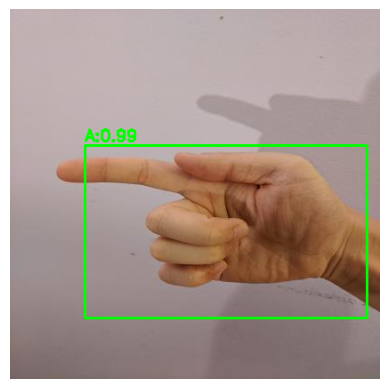

In [ ]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
import torchvision.transforms as T
import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_prediction_simple(img_tensor, prediction, id2name=None, score_thresh=0.5):
    # 텐서를 numpy로 변환
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    if img.max() <= 1:
        img = (img * 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # 예측 결과 시각화
    for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
        if score < score_thresh:
            continue

        x1, y1, x2, y2 = box.int().cpu().numpy()
        class_name = id2name.get(label.item(), str(label.item()))
        text = f"{class_name}:{score:.2f}"

        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0,255,0), 2)  # 초록 박스
        cv2.putText(img_bgr, text, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

        print(f"Pred 라벨: {class_name}, Score: {score:.2f}, Box: {box.cpu().numpy().astype(int)}")

    # 시각화 출력
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


# -----------------------------------------------------------
# 추론 코드
# -----------------------------------------------------------

# 1. 테스트 데이터셋 준비
test_img_dir = "/content/object/test"
test_ann_file = "/content/object/test/_annotations.coco.json"
test_dataset = CocoDetection(test_img_dir, test_ann_file, transform=T.ToTensor())

# COCO 데이터셋의 카테고리 매핑
id2name = {cat['id']: cat['name'] for cat in test_dataset.coco.cats.values()}

# 2. 모델 로드 (사전학습 가중치)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device).eval()

# 3. 첫 번째 이미지와 정답 라벨 출력
img_tensor, target = test_dataset[0]

print("=== Ground Truth (원래 라벨) ===")
for ann in target:
    class_id = ann['category_id']
    bbox = ann['bbox']  # coco 형식: [x,y,w,h]
    class_name = id2name.get(class_id, str(class_id))
    print(f"GT 라벨: {class_name}, Box: {bbox}")

# 4. 예측
with torch.no_grad():
    prediction = model(img_tensor.unsqueeze(0).to(device))[0]

print("\n=== Prediction (예측 라벨) ===")
show_prediction_simple(img_tensor, prediction, id2name=id2name, score_thresh=0.5)
